In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import sys

import json
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import font_manager
from scipy import constants as const
import numpy as np
import pandas as pd

%matplotlib inline

In [25]:
# where WellClass and Ga[ codes are located
sys.path.append("../")

from src.WellClass.libs.well_pressure.Pressure import Pressure
from src.WellClass.libs.well_pressure.PressureScenarioManager import PressureScenarioManager
from src.WellClass.libs.well_pressure.PressureScenario import PressureScenario
from src.WellClass.libs.pvt.pvt import get_rho_from_pvt_data, load_pvt_data, _integrate_pressure

# plots
from src.WellClass.libs.plotting import (
    plot_pressure,
)

In [26]:
# resource configuration
rcParams["figure.dpi"] = 200

# fount information
rcParams["font.family"] = "Equinor"
rcParams["font.size"] = 9

# fornt location
font_path = r"Equinor_regular"
font_files = font_manager.findSystemFonts(fontpaths=font_path)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

## WINC Examples

### Using predefined fluid curves

It can handle different fluid compositions if PVT tables are available. 
Currently there are 4 options:
- Pure CO2 (100 mol% CO2)
- Pure Methane (100 mol% CH4)
- Gas mixture 1 (96 mol% CO2, 0.4 mol% H2, 1 mol% Ar, 0.82 mol% N2, 1.78 mol% CH4)
- Gas mixture 2 (95 mol% CO2, 5 mol% CH4)


In [27]:
import os
# Retrieve PVT data that is available


directory_path = "../src/WellClass/libs/pvt/pvt_constants"

# Iterate over all files in the directory
for filename in os.listdir(directory_path):
    # print(filename)
    file_path = os.path.join(directory_path, filename)
    if os.path.isdir(file_path):
        print(f"{filename}")

water
mixture1
methane
pure_co2
mixture2


In [28]:
import json

with open("winc_payload.json") as f:
    json_data = json.load(f)


In [29]:
field_fluid_type = "pure_co2"
field_pressure_value = 450
field_depth_value = 4200
delta_p = 50
# shmin_data = pd.read_csv(r"predict.txt").values
shmin_data = np.array(json_data["shMinOriginal"])
sf_depth_msl = json_data["waterDepth"]


In [30]:
my_pressure = Pressure(
    # wellbore seafloor depth mTVD MSL.
    sf_depth_msl=sf_depth_msl,  # wellbore.water_depth,
    # wellbore total depth in mTVD RKB
    well_td_rkb=8000,  # total_depth_rkb,
    # wellbore rkb in mTVD RKB
    well_rkb=62.8,
    # seafloor temperature in degC
    sf_temp=4,  # DEFAULT_SEAFLOOR_TEMPERATURE,
    # geothermal gradient in degC/km
    geo_tgrad=40,  # DEFAULT_GEOTHERMAL_GRADIENT,
    fluid_type=field_fluid_type,  # type: ignore
    # path to the pvt constants folder
    pvt_path=directory_path,
    # z_fluid_contact=field_depth_value,  # wellbore_settings.pressure_datum_tvd_msl,  # type: ignore
    # p_fluid_contact=field_pressure_value,  # wellbore_settings.reservoir_pressure_bar,  # type: ignore
    # specific_gravity=None,  # type: ignore
    ip_shmin_data=shmin_data,
    rho_brine=1050,
)


i = 0
my_pressure.add_scenario(
    scenario_name=str(i + 1),
    fluid_type=field_fluid_type,  # type: ignore
    from_resrvr=True,
    z_fluid_contact=1768.9,
    p_fluid_contact = 183.19,
    cleanup_curves=False
    # specific_gravity=specific_gravity,  # type: ignore
)

my_pressure.add_scenario(
    scenario_name=str(i + 2),
    fluid_type=field_fluid_type,  # type: ignore
    from_resrvr=True,
    z_fluid_contact=1263.9,
    p_fluid_contact = 100,
    cleanup_curves=False

    # specific_gravity=specific_gravity,  # type: ignore
)


my_pressure.add_scenario(
    scenario_name=str(i + 3),
    fluid_type=field_fluid_type,  # type: ignore
    from_resrvr=True,
    z_fluid_contact=1263.9,
    p_fluid_contact = 70,
    cleanup_curves=False

    # specific_gravity=specific_gravity,  # type: ignore
)

/workspaces/WINC_OnePager/notebooks/../src/WellClass/libs/well_pressure/Pressure.py:212: UserWarning: No Shmin data between seafloor depth (109) and minimum provided depth (111.18364). Extrapolating using hydrostatic pressure at seafloor.
  warnings.warn(


Computing pressure profile for scenario: 1
Computing pressure profile for scenario: 2
Computing pressure profile for scenario: 3


In [31]:
from pathlib import Path
import os

root_path = Path('../src/WellClass/libs/pvt/pvt_constants')


co2_p_path = root_path / 'pressure.txt'
co2_T_path = root_path / 'temperature.txt'
co2_rho_path = root_path / 'pure_co2' / 'rho.txt'


co2_p = np.loadtxt(co2_p_path)
co2_T = np.loadtxt(co2_T_path)
co2_rho = np.loadtxt(co2_rho_path, delimiter=",")






652.392120411555
318.6284431657705
318.5761717642804


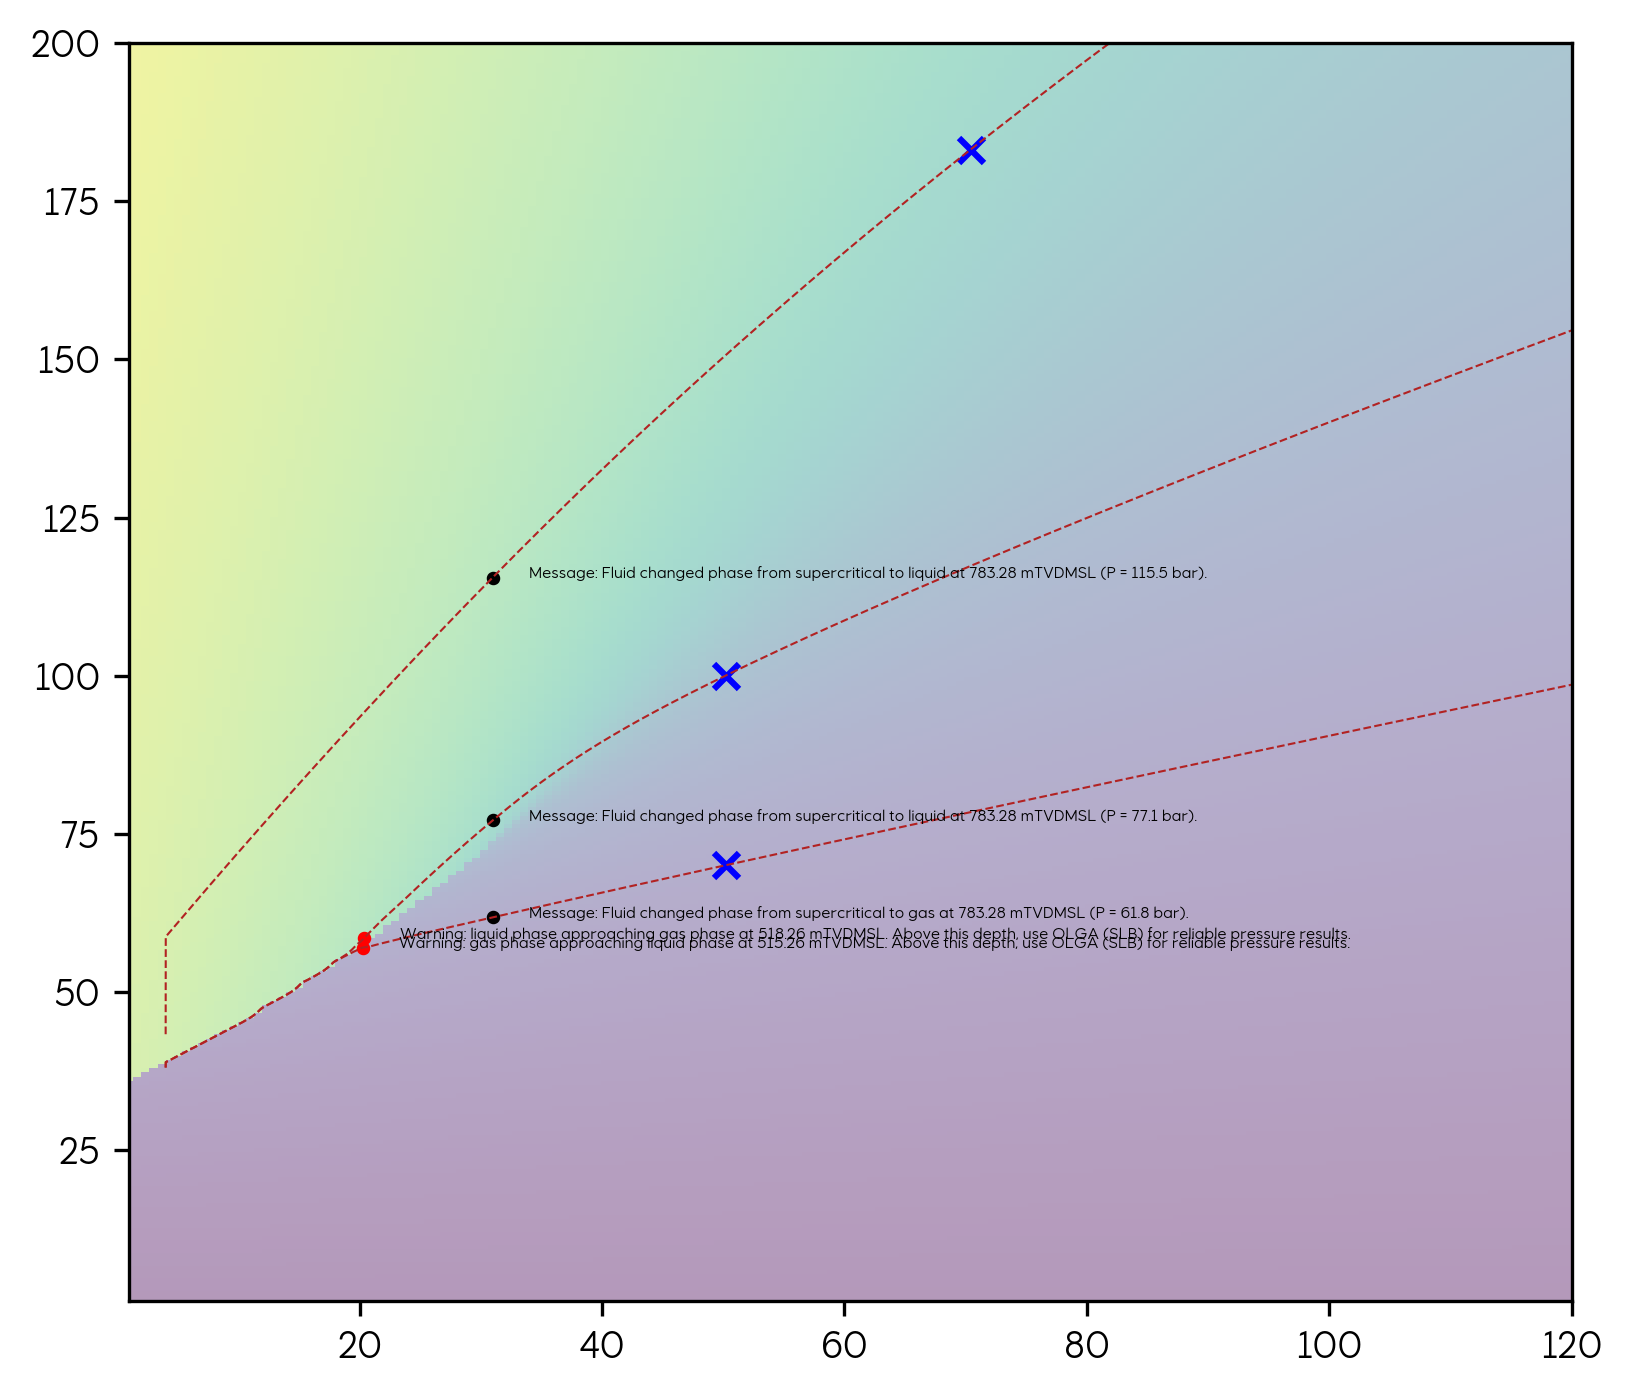

In [32]:
rcParams["figure.dpi"] = 300

width_cm = 14  # cm
height_cm = 12  # cm

width = width_cm / 2.54
height = height_cm / 2.54

fig, ax = plt.subplots(1, 1, figsize=(width, height))

# plot_pressure(
#     my_pressure,
#     ax=ax,
#     plot_HSP=True,  # plot brine hydrostatic gradient
#     plot_MSAD=True,  # plot minimum safety abandonment depth,
#     plot_fluid_contact=True,  # plot fluid contact
#     plot_resrv=False,  # plot reservoir
#     plot_delta_p=False,  # plot delta p
# )

# ax.plot(my_pressure.init_curves["min_horizontal_stress"], my_pressure.init_curves["depth"], c="k", lw=1)

ax.pcolormesh(co2_T, co2_p, co2_rho, alpha = 0.4)

scenarios = my_pressure.scenario_manager.scenarios


for scenario in scenarios:
    print(scenarios[scenario].z_MSAD)

    data_table = scenarios[scenario].init_curves

    # ax.plot(data_table["temperature"], data_table["brine_pressure"], color="steelblue", ls="--", lw=0.5)
    ax.plot(data_table["temperature"], data_table["fluid_pressure"], color="firebrick", ls="--", lw=0.5)

    # ax.scatter(scenarios[scenario].p_MSAD, scenarios[scenario].z_MSAD, color="firebrick", s=10)

    z_fluid_contact = scenarios[scenario].z_fluid_contact
    p_fluid_contact = scenarios[scenario].p_fluid_contact
    T_fluid_contact = np.interp(z_fluid_contact, data_table.depth, data_table.temperature)

    ax.scatter(T_fluid_contact, p_fluid_contact, marker='x', color ='blue')
    

    for warning in scenarios[scenario].warnings:
        if 'message' in warning["message"].lower():
            cmsg = 'black'
        else:
            cmsg = 'red'        
        ax.scatter(warning["T"], warning["p"], s=5, c=cmsg)
        ax.annotate(warning["message"], xy=(warning["T"], warning["p"]), xytext=(warning["T"] + 3, warning["p"]), size=4)


# ax.axhline(y=my_pressure.z_fluid_contact, color="blue", linestyle="--", label="Fluid contact", lw = 1)

# ax.plot(shmin_data[:, 1], shmin_data[:, 0], color="green", linestyle="-", label="Input SHmin data")
# ax.plot(json_data['shMin'], json_data['depthAxis'])
# ax.plot(json_data['pressureScenarios'][0]['co2'], json_data['depthAxis'], c='r')
# ax.plot(json_data['pressureScenarios'][1]['co2'], json_data['depthAxis'], c='r', ls=':')
# ax.scatter(json_data['pressureScenarios'][0]['msadPressure'],json_data['pressureScenarios'][0]['msadDepth'], c='black', marker='x', s=50, label='MSAD Point Scenario 1')
# ax.scatter(json_data['pressureScenarios'][1]['msadPressure'],json_data['pressureScenarios'][1]['msadDepth'], c='black', marker='x', s=50, label='MSAD Point Scenario 1')

ax.set_xlim(1, 120)
ax.set_ylim(1, 200)

fig.tight_layout()

In [19]:
my_pressure.scenario_manager.scenarios['2'].init_curves

,depth,temperature,hydrostatic_pressure,min_horizontal_stress,fluid_pressure,brine_pressure
0,-62.800000,4.000000,-5.453255,-5.453255,37.996175,-36.610067
1,-61.799904,4.000000,-5.350275,-5.350275,37.999086,-36.507087
2,-60.799807,4.000000,-5.247296,-5.247296,38.001955,-36.404107
3,-59.799711,4.000000,-5.144316,-5.144316,38.004782,-36.301128
4,-58.799614,4.000000,-5.041336,-5.041336,38.007569,-36.198148
...,...,...,...,...,...,...
8295,8232.999614,328.959985,848.763780,1808.150610,293.373209,817.606968
8296,8233.999711,328.999988,848.866759,1808.380430,293.398731,817.709947
8297,8234.999807,329.039992,848.969739,1808.610249,293.424252,817.812927
8298,8235.999904,329.079996,849.072719,1808.840069,293.449774,817.915907


652.392120411555
318.6284431657705
318.5761717642804


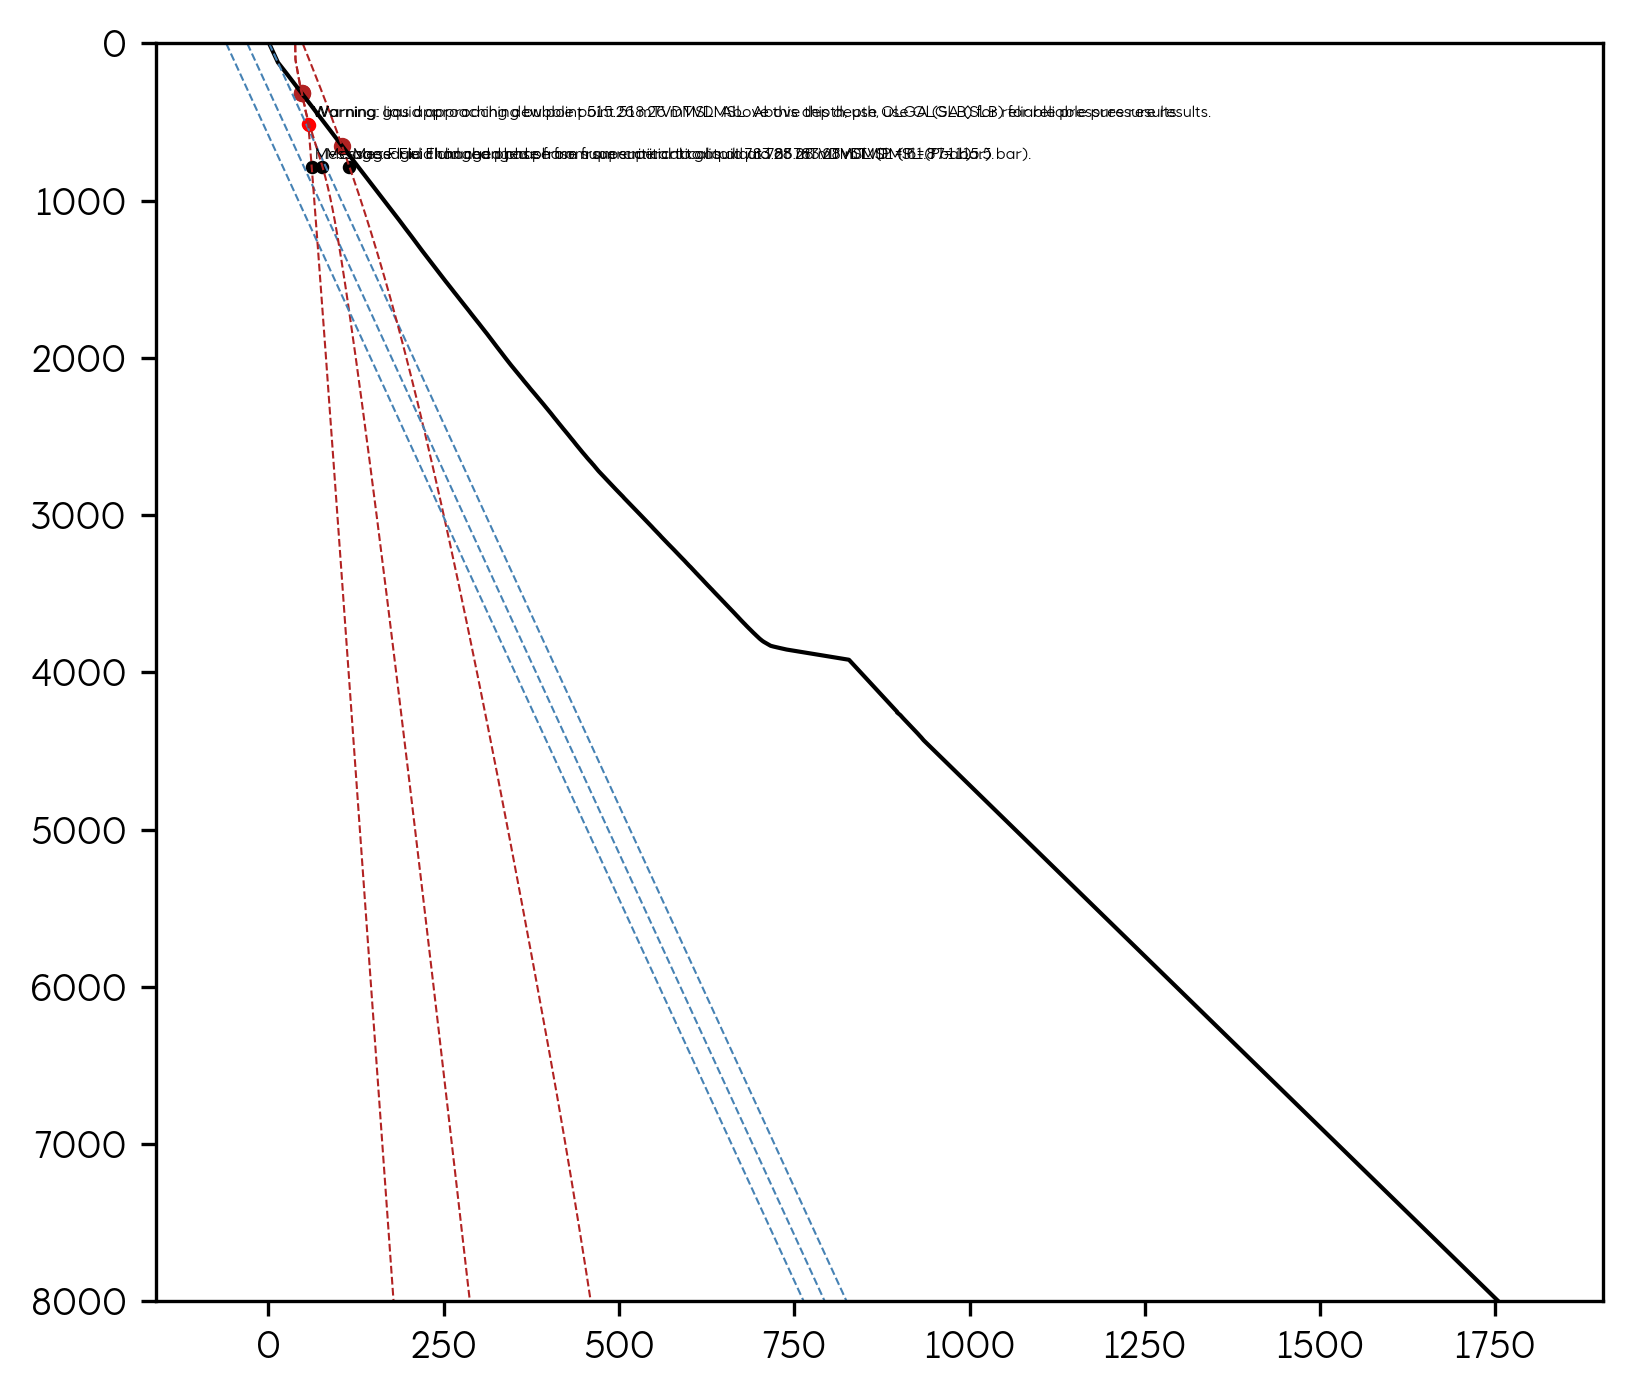

In [71]:
rcParams["figure.dpi"] = 300

width_cm = 14  # cm
height_cm = 12  # cm

width = width_cm / 2.54
height = height_cm / 2.54

fig, ax = plt.subplots(1, 1, figsize=(width, height))

# plot_pressure(
#     my_pressure,
#     ax=ax,
#     plot_HSP=True,  # plot brine hydrostatic gradient
#     plot_MSAD=True,  # plot minimum safety abandonment depth,
#     plot_fluid_contact=True,  # plot fluid contact
#     plot_resrv=False,  # plot reservoir
#     plot_delta_p=False,  # plot delta p
# )

ax.plot(my_pressure.init_curves["min_horizontal_stress"], my_pressure.init_curves["depth"], c="k", lw=1)


scenarios = my_pressure.scenario_manager.scenarios


for scenario in scenarios:
    print(scenarios[scenario].z_MSAD)

    data_table = scenarios[scenario].init_curves

    ax.plot(data_table["brine_pressure"], data_table["depth"], color="steelblue", ls="--", lw=0.5)
    ax.plot(data_table["fluid_pressure"], data_table["depth"], color="firebrick", ls="--", lw=0.5)

    ax.scatter(scenarios[scenario].p_MSAD, scenarios[scenario].z_MSAD, color="firebrick", s=10)

    for warning in scenarios[scenario].warnings:
        if 'message' in warning["message"].lower():
            cmsg = 'black'
        else:
            cmsg = 'red'                
        ax.scatter(warning["p"], warning["z"], color = cmsg, s=5)
        ax.annotate(warning["message"], xy=(warning["p"], warning["z"]), xytext=(warning["p"] + 5, warning["z"] - 50), size = 4)


# ax.axhline(y=my_pressure.z_fluid_contact, color="blue", linestyle="--", label="Fluid contact", lw = 1)

# ax.plot(shmin_data[:, 1], shmin_data[:, 0], color="green", linestyle="-", label="Input SHmin data")
# ax.plot(json_data['shMin'], json_data['depthAxis'])
# ax.plot(json_data['pressureScenarios'][0]['co2'], json_data['depthAxis'], c='r')
# ax.plot(json_data['pressureScenarios'][1]['co2'], json_data['depthAxis'], c='r', ls=':')
# ax.scatter(json_data['pressureScenarios'][0]['msadPressure'],json_data['pressureScenarios'][0]['msadDepth'], c='black', marker='x', s=50, label='MSAD Point Scenario 1')
# ax.scatter(json_data['pressureScenarios'][1]['msadPressure'],json_data['pressureScenarios'][1]['msadDepth'], c='black', marker='x', s=50, label='MSAD Point Scenario 1')

ax.set_ylim(bottom=8000, top=0)
fig.tight_layout()

In [82]:
my_pressure.scenarios_summary()

,name,from_resrvr,z_MSAD,p_MSAD,z_MSAD_brine,p_MSAD_brine,z_resrv,p_resrv,z_fluid_contact,p_fluid_contact,p_delta,fluid_type,fluid_composition,specific_gravity
0,hydrostatic,True,1677.309323,281.926827,354.297182,54.008654,4200,450,4200,450,16.513485,pure_co2,100% CO2,None
1,1,True,2144.677852,364.170190,1079.102558,178.641737,4200,500,4200,500,66.513485,pure_co2,100% CO2,None


In [ ]:
for scenario in json_data["pressureScenarios"]:
    print(f"Scenario {scenario['name']}:\n\tMSAD Depth = {scenario['msadDepth']} mTVD MSL, MSAD Pressure = {scenario['msadPressure']} bar")

Scenario hydrostatic:
	MSAD Depth = 1684.8530493118712 mTVD MSL, MSAD Pressure = 283.2450527505069 bar
Scenario 1:
	MSAD Depth = 2145.077027498919 mTVD MSL, MSAD Pressure = 364.23619566162904 bar


In [ ]:
my_pressure.scenario_manager.scenarios["hydrostatic"].init_curves.loc[1684:1685]

,depth,temperature,hydrostatic_pressure,min_horizontal_stress,fluid_pressure,brine_pressure
1684.000000,1684.000000,67.00,169.654718,283.084790,NaN,207.424585
1684.853049,1684.853049,67.02,169.704253,283.245053,283.245053,207.474238
1685.000000,1685.000000,67.04,169.753788,283.272660,283.256379,207.523891


In [ ]:
my_pressure.scenario_manager.scenarios["1"].init_curves.loc[2145:2146]

,depth,temperature,hydrostatic_pressure,min_horizontal_stress,fluid_pressure,brine_pressure
2145.000000,2145.000000,85.44,215.127174,364.223459,NaN,302.684985
2145.077027,2145.077027,85.46,215.176267,364.236196,364.236196,302.734322
2146.000000,2146.000000,85.48,215.225360,364.388814,364.306779,302.783659


In [ ]:
*